# **Heart disease risk from tabular clinical data**

**Audience.** Clinicians, health services researchers, and data scientists who want a **transparent, reproducible** workflow.

**Scope and limitations.** This notebook is **educational and methodological**. It is **not** a validated clinical prediction instrument, regulatory artifact, or substitute for history, examination, and institutional protocols. Results on pooled public data **must not** be extrapolated to individual patient decisions without independent validation, governance review, fairness assessment, and monitoring.

**Outcome definition.** The label `num` (0–4) is collapsed to **binary angiographic disease** (`num > 0`: any non-zero severity vs none). This simplifies presentation but **discards severity grading**.

Dataset: UCI Heart Disease (https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data/data)

---

**Diego Armando Salinas Lugo**

*salinas.diegoarmando03@gmail.com*



In [ ]:
# Libraries — versions affect numerics; pin via requirements.txt for audits.
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import loguniform, randint

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from sklearn.metrics import (
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import (
    cross_validate,
    RandomizedSearchCV,
    StratifiedKFold,
    LeaveOneGroupOut,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    import shap

    _HAS_SHAP = True
except ImportError:
    _HAS_SHAP = False

try:
    import lime
    from lime.lime_tabular import LimeTabularExplainer

    _HAS_LIME = True
except ImportError:
    _HAS_LIME = False

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
warnings.filterwarnings("ignore", category=UserWarning)


### Data source and file location

The next cell downloads the **Heart Disease UCI** bundle (KaggleHub) into this project’s `data/` directory when needed, then loads `heart_disease_uci.csv` into `df`. The column **`dataset`** identifies study site or hospital; pooled files combine cohorts with different prevalence and missingness.

**Citation context.** The Cleveland subset is widely referenced; multi-site aggregates are **hypothesis-generating** unless harmonization and prospective validation are performed.


In [2]:
from pathlib import Path
import kagglehub

# Store data under the project path for reproducibility and auditability.
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

path = kagglehub.dataset_download(
    "redwankarimsony/heart-disease-data",
    output_dir=str(DATA_DIR),
)

print("Downloaded dataset location:", path)


Downloaded dataset location: /Users/diegoarmandosalinaslugo/Documents/Learning/ML_practice/data


In [3]:
df = pd.read_csv("data/heart_disease_uci.csv")

### Record-level preview

Inspect the first rows for **implausible values**, inconsistent typing, and coding conventions before summarizing or modeling.


In [4]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


### Variable groups (data dictionary)

| Group | Fields | Note |
|-------|--------|------|
| Identifier (excluded from predictors) | `id` | Arbitrary identifier. |
| Demographics / context | `age`, `sex`, `dataset` | `dataset` encodes **study site** (important confounder in pooled data). |
| Resting measures | `cp`, `trestbps`, `chol`, `fbs`, `restecg` | Chest pain type, blood pressure, lipids, fasting glucose, resting ECG. |
| Exercise test | `thalch`, `exang`, `oldpeak`, `slope` | Max heart rate, exercise angina, ST change, slope. |
| Angiography / imaging (often incomplete) | `ca`, `thal` | **High missingness** in some sites. |
| Label | `num` (0–4) | Severity bucket; modeled as **binary** `num > 0` here. |


## Exploratory data analysis

Figures and tables in this section use the **entire loaded cohort** for characterization. **Imputers and scalers are not fit here** — they are estimated only on the training split inside the modeling pipeline, avoiding leakage from the test set.


### Numeric summaries

`describe()` summarizes scale and central tendency. Columns whose **count** is below the number of rows indicate **partial missingness**.


In [5]:
summary = df.describe()
n = len(df)
thin = [c for c in summary.columns if summary.loc["count", c] < n]
if thin:
    print("Numeric cols with gaps (count < rows):", thin)
summary


Numeric cols with gaps (count < rows): ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


### Column data types

`info()` lists dtypes and non-null counts to support consistent encoding in the modeling pipeline.


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


### Missing values — counts and prevalence

Sorted missing counts, a bar chart, and a **matrix view** in the next cell. Variables with **>30%** missing are flagged; inference that depends on them should be interpreted cautiously.


>30% missing: {'ca': np.int64(611), 'thal': np.int64(486), 'slope': np.int64(309)}


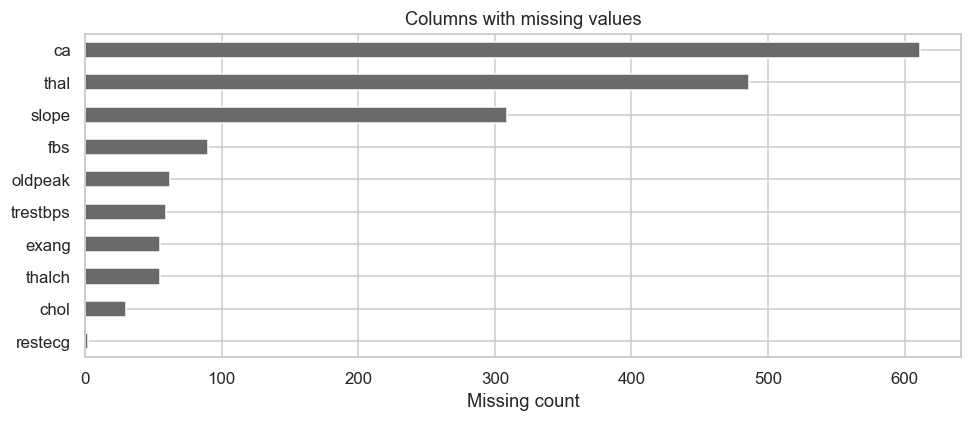

In [7]:
miss = df.isnull().sum().sort_values(ascending=False)
n = len(df)
severe = miss[miss > 0.3 * n]
if len(severe) > 0:
    print(">30% missing:", dict(severe))
miss_nz = miss[miss > 0]
if len(miss_nz) > 0:
    plt.figure(figsize=(9, 4))
    miss_nz.sort_values().plot(kind="barh", color="dimgray")
    plt.xlabel("Missing count")
    plt.title("Columns with missing values")
    plt.tight_layout()
    plt.show()


**Reading this plot.**
- Three angiography/imaging fields (`ca`, `thal`, `slope`) account for nearly all of the missingness; most non-imaging clinical measures are largely complete.
- Any effect attributed to those three features in the modeling section is estimated on a minority of patients — interpret their coefficients or importances cautiously, and expect them to contribute less to a robust out-of-site prediction.
- Median/mode imputation is a reasonable default for the low-missingness columns; for the imaging trio it is a compromise rather than a principled reconstruction. Alternatives (dropping them, modeling missingness indicators, multiple imputation) are plausible extensions outside the scope of this notebook.

### Missing-data matrix (binary heatmap)

**Dark** cells indicate observed values; **light** cells indicate missing. This visualization highlights **which variables** and **which records** are incomplete. Columns may appear in table order; consider sorting by missingness when comparing sites.


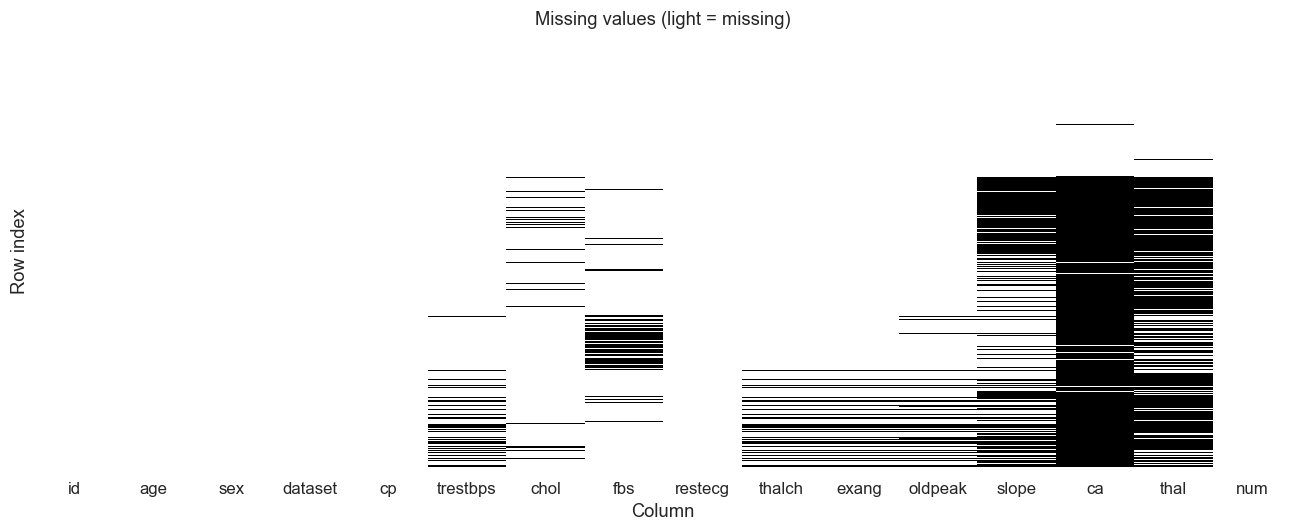

In [8]:
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="binary")
plt.title("Missing values (light = missing)")
plt.xlabel("Column")
plt.ylabel("Row index")
plt.tight_layout()
plt.show()


**Reading this plot.**
- Missingness is **not randomly scattered across rows**. `slope`, `ca`, and `thal` show contiguous bands of missing values spanning large row ranges; `chol` and `fbs` also have block-like gaps.
- Those blocks align with study site — certain hospitals never recorded certain measurements. The pattern is therefore **missing-by-site**, not missing-at-random within patients.
- This is the empirical justification for the **leave-one-site-out check** in the modeling section. If a model leans on features that are effectively site-indicator artifacts rather than patient physiology, LOSO will expose it as performance that does not transport across sites.

### Outcome distribution

Distribution of raw `num` (0–4) and the **binary** outcome `num > 0` (counts and percentages). Subsequent plots relate continuous measures to this binary outcome.


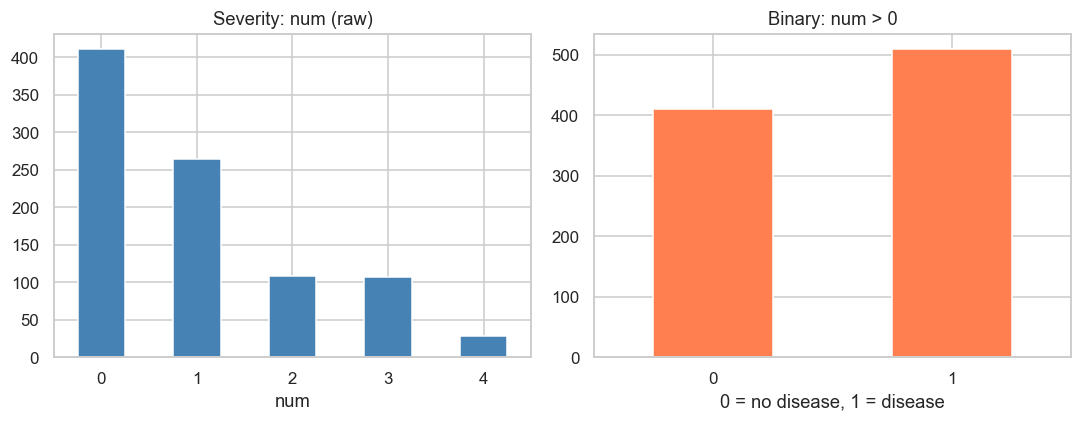

Severity label num (categories 0–4) — count and % of cohort:
  num=0: 411 (44.7%)
  num=1: 265 (28.8%)
  num=2: 109 (11.8%)
  num=3: 107 (11.6%)
  num=4: 28 (3.0%)

Binary outcome (num > 0) — count and % of cohort:
  0 (no disease): 411 (44.7%)
  1 (disease): 509 (55.3%)


In [9]:
eda_binary = (df["num"] > 0).astype(int)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
df["num"].value_counts().sort_index().plot(kind="bar", ax=ax[0], color="steelblue", rot=0)
ax[0].set_title("Severity: num (raw)")
ax[0].set_xlabel("num")
eda_binary.value_counts().sort_index().plot(kind="bar", ax=ax[1], color="coral", rot=0)
ax[1].set_title("Binary: num > 0")
ax[1].set_xlabel("0 = no disease, 1 = disease")
plt.tight_layout()
plt.show()

vc_num = df["num"].value_counts().sort_index()
vc_bin = eda_binary.value_counts().sort_index()
n = len(df)
print("Severity label num (categories 0–4) — count and % of cohort:")
for k, v in vc_num.items():
    print(f"  num={k}: {v} ({100 * v / n:.1f}%)")
print("\nBinary outcome (num > 0) — count and % of cohort:")
for k, v in vc_bin.items():
    label = "no disease" if k == 0 else "disease"
    print(f"  {k} ({label}): {v} ({100 * v / n:.1f}%)")


**Reading this plot.**
- Raw severity `num` is right-skewed; categories 2–4 are individually too small to model reliably as separate classes.
- Collapsing to binary produces a roughly balanced target (modest tilt toward the disease class).
- Because the binary outcome is close to balanced, threshold-free metrics (ROC-AUC) and standard classification metrics are appropriate without resampling or heavy class-weight adjustments.

### Age and maximum heart rate by outcome

Kernel-density overlays compare **age** and **max heart rate (`thalch`)** between participants with and without `num > 0`. These are **unadjusted** marginal comparisons.


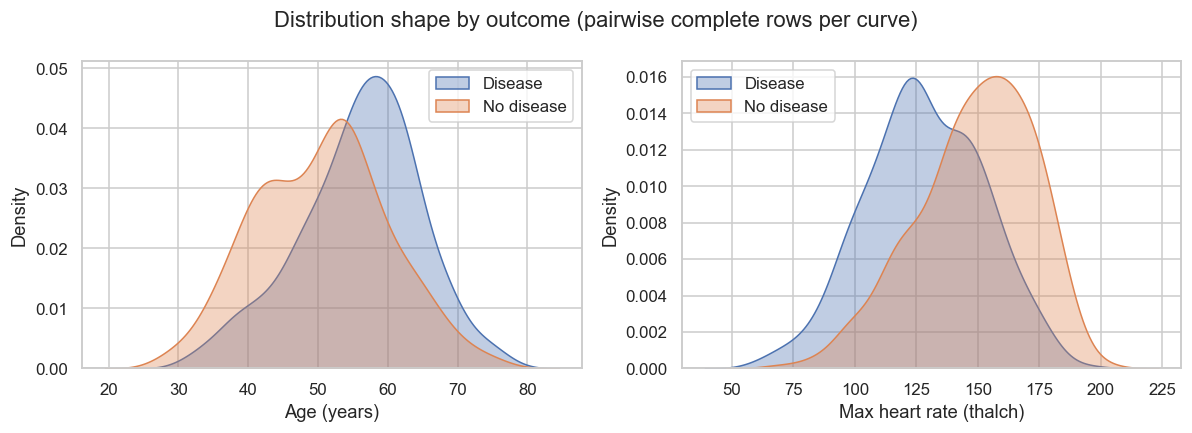

In [10]:
plot_df = df.assign(disease=(df["num"] > 0).astype(int).map({0: "No disease", 1: "Disease"}))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, xlab in zip(axes, ["age", "thalch"], ["Age (years)", "Max heart rate (thalch)"]):
    for label, sub in plot_df.groupby("disease"):
        sns.kdeplot(data=sub, x=col, ax=ax, label=label, warn_singular=False, fill=True, alpha=0.35)
    ax.set_xlabel(xlab)
    ax.legend(title="")
plt.suptitle("Distribution shape by outcome (pairwise complete rows per curve)")
plt.tight_layout()
plt.show()


**Reading this plot.**
- Age distributions overlap substantially. Disease is shifted toward older patients, but age alone does not separate the outcome classes.
- `thalch` shows stronger separation — lower peak exercise heart rate is more common in the disease group, consistent with an ischemic response limiting exertion.
- These are **unadjusted marginal** comparisons — no control for site, sex, medication, or comorbidity. They are useful as screening signals, not as evidence of isolated effects.

### Correlations among numeric features

Heatmap of **linear (Pearson) correlations** and the strongest correlations with `num`. Correlation does not imply causation and is sensitive to outliers and pooling across sites.

Next: scatter of **age vs max HR** colored by outcome.


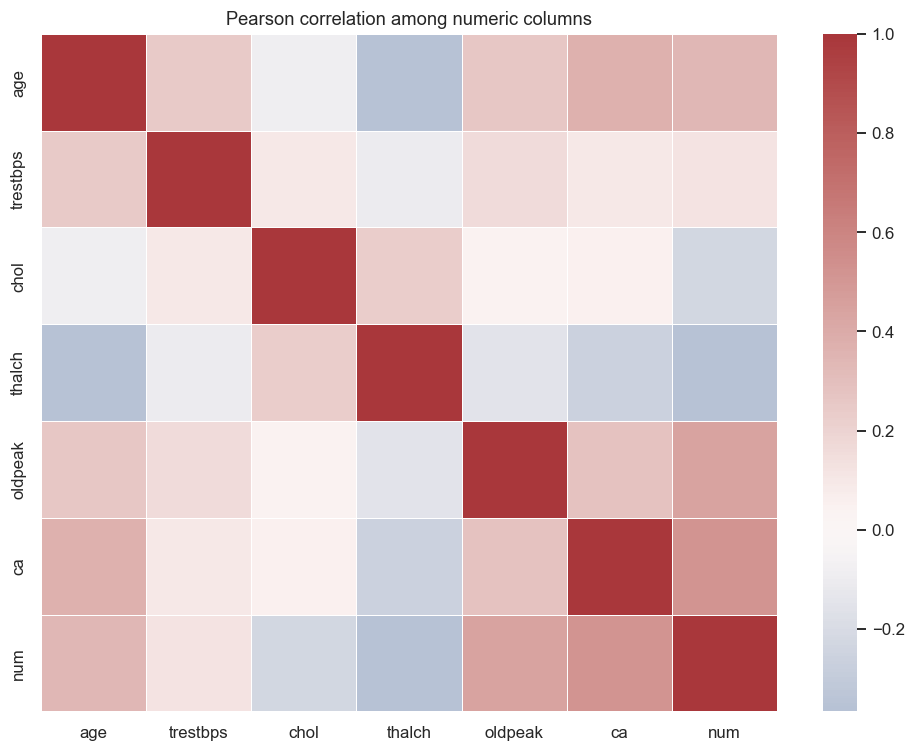

Strongest linear relationships with num (by |correlation|):
  ca          + |r| = 0.516
  oldpeak     + |r| = 0.443
  thalch      - |r| = 0.366
  age         + |r| = 0.340
  chol        - |r| = 0.232
  trestbps    + |r| = 0.122


In [11]:
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "id"]
corr = df[num_cols].corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap="vlag", center=0, linewidths=0.5)
plt.title("Pearson correlation among numeric columns")
plt.tight_layout()
plt.show()

if "num" in corr.index:
    with_num = corr["num"].drop(labels=["num"]).abs().sort_values(ascending=False)
    print("Strongest linear relationships with num (by |correlation|):")
    for feat, val in with_num.head(6).items():
        raw = corr.loc[feat, "num"]
        sign = "+" if raw >= 0 else "-"
        print(f"  {feat:10s}  {sign} |r| = {abs(raw):.3f}")
else:
    print("Column 'num' not found in correlation matrix.")


**Reading this plot.**
- The strongest linear relationships with `num` are `ca` (positive), `oldpeak` (positive), `thalch` (negative), and `age` (positive) — each consistent with established clinical directionality.
- Inter-feature correlations are present but modest; no feature is a near-duplicate of another, so no predictor needs to be dropped on redundancy grounds.
- Pearson captures only linear monotonic trends. A weak correlation here does not mean a feature is uninformative to tree-based models, which can exploit thresholds, interactions, and non-linear relationships the heatmap cannot show.

### Bivariate view (age vs maximum heart rate)

Joint distribution colored by disease flag; patterns may be absent in marginal views alone.


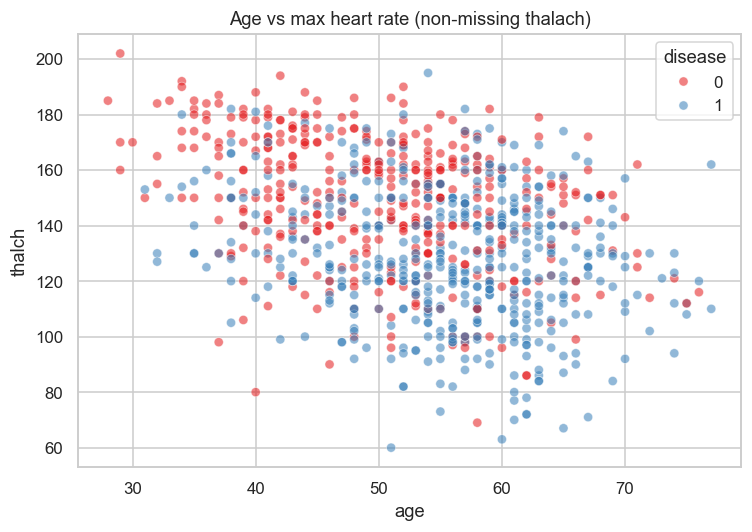

In [12]:
sc = df.assign(disease=(df["num"] > 0).astype(int)).dropna(subset=["age", "thalch"])
plt.figure(figsize=(7, 5))
sns.scatterplot(data=sc, x="age", y="thalch", hue="disease", alpha=0.55, palette="Set1")
plt.title("Age vs max heart rate (non-missing thalach)")
plt.tight_layout()
plt.show()


**Reading this plot.**
- The two outcome classes occupy partly overlapping regions of the joint space; disease is concentrated toward the lower-HR side at any given age band.
- The overall downward slope reflects the expected physiological decline of peak heart rate with age, visible independently of outcome.
- The degree of overlap tells us no linear rule on this 2-D projection will achieve high separation alone — the model will need the remaining features to improve on the signal visible here.

### Continuous clinical features vs outcome

Box plots and printed medians compare resting and exercise-related measures between outcome groups.


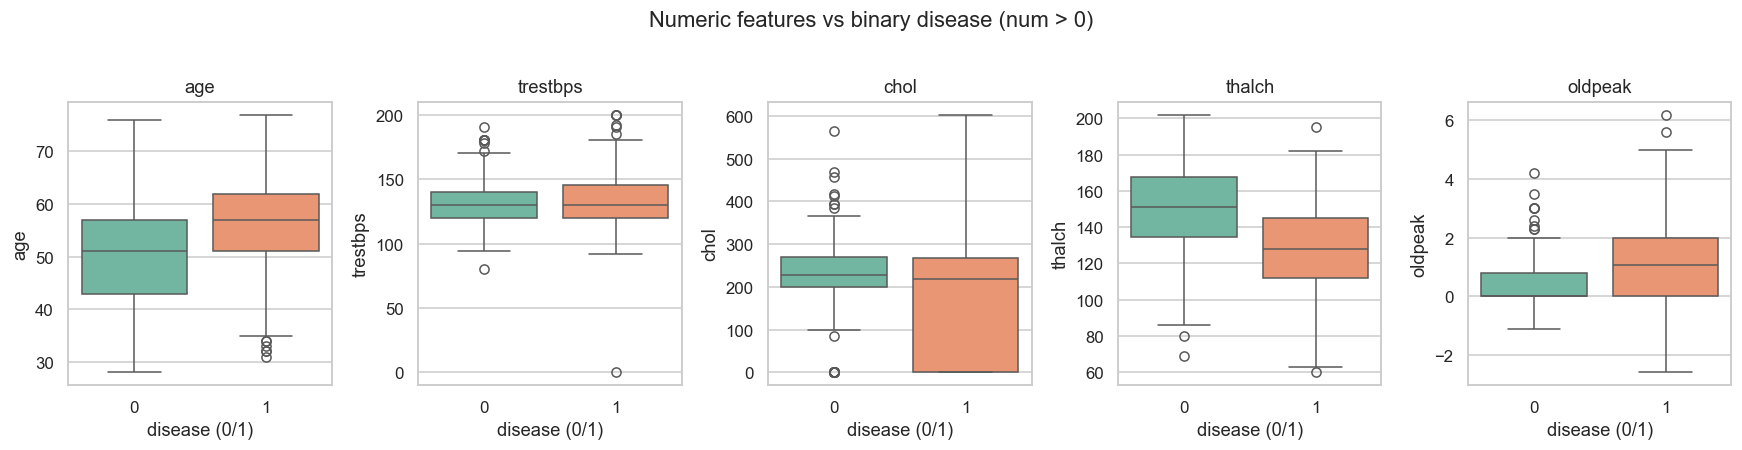

In [13]:
plot_df = df.assign(disease=(df["num"] > 0).astype(int))
plot_cols = [c for c in ["age", "trestbps", "chol", "thalch", "oldpeak"] if c in df.columns]
fig, axes = plt.subplots(1, len(plot_cols), figsize=(3.2 * len(plot_cols), 4))
if len(plot_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, plot_cols):
    sns.boxplot(
        data=plot_df,
        x="disease",
        y=col,
        ax=ax,
        hue="disease",
        palette="Set2",
        legend=False,
    )
    ax.set_title(col)
    ax.set_xlabel("disease (0/1)")
plt.suptitle("Numeric features vs binary disease (num > 0)", y=1.02)
plt.tight_layout()
plt.show()



**Reading this plot.**
- `oldpeak` and `thalch` show the clearest separation between outcome groups — consistent with the correlation heatmap and the earlier KDEs.
- `age` shows a modest but consistent upward shift in the disease group.
- **Watch the outliers in `chol` and `trestbps`.** Several rows have values of `0`, which are clinically implausible (no one has a resting blood pressure or serum cholesterol of zero). These are almost certainly **sentinel codes for missing data** recorded as numeric zero rather than NaN. The `SimpleImputer(strategy="median")` used in the modeling pipeline only fills true NaNs, so those zeros will remain in the training matrix and pull the median imputation downward. This is addressed in the **Data cleaning — sentinel zeros** section immediately below, which maps those zeros to `NaN` *before* the pipeline so the median imputer can act on them.

### Categorical factors vs outcome

Counts for chest pain type and sex, with row-percentage tables. Next: **prevalence by study site**.


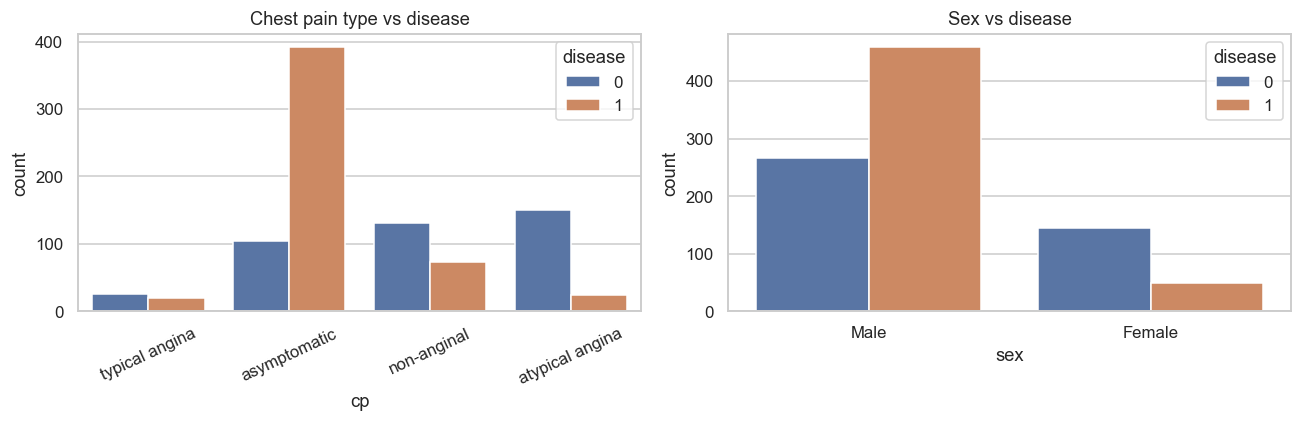

Row % within each chest pain type (columns sum to 100% per cp level):
disease             0     1
cp                         
asymptomatic     21.0  79.0
atypical angina  86.2  13.8
non-anginal      64.2  35.8
typical angina   56.5  43.5

Row % within each sex:
disease     0     1
sex                
Female   74.2  25.8
Male     36.8  63.2


In [14]:
cat_df = df.assign(disease=(df["num"] > 0).astype(int))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=cat_df, x="cp", hue="disease", ax=axes[0])
axes[0].tick_params(axis="x", rotation=25)
axes[0].set_title("Chest pain type vs disease")
sns.countplot(data=cat_df, x="sex", hue="disease", ax=axes[1])
axes[1].set_title("Sex vs disease")
plt.tight_layout()
plt.show()

print("Row % within each chest pain type (columns sum to 100% per cp level):")
cp_ct = pd.crosstab(cat_df["cp"], cat_df["disease"], normalize="index") * 100
print(cp_ct.round(1).to_string())
print("\nRow % within each sex:")
sx_ct = pd.crosstab(cat_df["sex"], cat_df["disease"], normalize="index") * 100
print(sx_ct.round(1).to_string())


**Reading this plot.**
- Chest pain type is strongly outcome-associated: **asymptomatic** patients have by far the highest disease prevalence. This is counter-intuitive outside of a referral context — in an angiography-referred cohort, patients without classic angina who were nonetheless referred are disproportionately the ones with demonstrable disease. Tree-based models will likely split on `cp` early.
- The sex distribution is imbalanced (more men than women), and male patients carry a higher disease prevalence in this cohort. Models will pick up on this, but remember the imbalance reflects *cohort composition*, not population-level epidemiology.
- Both `cp` and `sex` are strong candidate predictors. `sex` in particular warrants scrutiny during interpretation, because in pooled multi-site data it can act as a proxy for site-level differences rather than an independent physiological effect.

## Data cleaning — sentinel zeros

The EDA boxplot in the "Continuous clinical features vs outcome" section revealed clinically implausible `0` values in `chol` and `trestbps`. No one has a resting blood pressure or serum cholesterol of zero; these are almost certainly **missing-data sentinels** recorded as numeric zeros rather than as `NaN`. The `SimpleImputer(strategy="median")` inside the modeling pipeline only fills true `NaN`s, so without this step the zeros would remain in the training matrix, bias the median imputations downward, and — as the SHAP analysis later confirms — produce a spurious "low cholesterol → disease" association.

This transformation is **deterministic and parameter-free** (zero → `NaN`, no value is learned from the data), so it is safe to apply before the train/test split. The imputation that does depend on the data (the median itself) still happens only inside the pipeline, fit per cross-validation fold.

In [15]:
sentinel_zero_cols = ["chol", "trestbps"]

for col in sentinel_zero_cols:
    if col not in df.columns:
        continue
    mask = df[col] == 0
    n_fixed = int(mask.sum())
    if n_fixed:
        df.loc[mask, col] = np.nan
        print(f"{col:10s}: {n_fixed} zero value(s) converted to NaN")
    else:
        print(f"{col:10s}: no zero values to clean")

print("\nMissing counts after cleaning (cleaned columns only):")
print(df[sentinel_zero_cols].isnull().sum().to_string())


chol      : 172 zero value(s) converted to NaN
trestbps  : 1 zero value(s) converted to NaN

Missing counts after cleaning (cleaned columns only):
chol        202
trestbps     60


## Preprocessing

The EDA above used the **full cohort** purely for characterization. From this point on, every step that **learns** from the data (imputation medians, scaler means/SDs, one-hot category inventories) must be **fit only on the training split** to avoid leakage from the held-out test set.

Design choices:

- **Target.** Binary `y = (num > 0)` — any angiographic disease vs none.
- **Predictors.** Drop `id` (arbitrary) and `num` (label). `dataset` (study site) is **kept as a grouping variable** for a later leave-one-site-out check; it is **not** used as a predictor because it encodes site-level confounding rather than patient physiology.
- **Numeric pipeline.** Median imputation (robust to skew and outliers seen in `chol`, `oldpeak`) + `StandardScaler` (required for the L2-regularized logistic baseline; harmless for trees).
- **Categorical pipeline.** Most-frequent imputation + `OneHotEncoder(handle_unknown="ignore")` so rare/new categories at test time do not crash the pipeline.
- **Split.** Stratified on `y` to preserve the ~55% disease prevalence in both partitions. A fixed seed (`RANDOM_STATE = 42`) is used for reproducibility.

All of this is wrapped in a `ColumnTransformer` that will be composed with each estimator inside a `Pipeline` during modeling — so cross-validation refits the preprocessor on each training fold.

### Target, predictors, and feature groups

`X` excludes the identifier (`id`), the raw label (`num`), and the site indicator (`dataset`, retained separately as `groups`). Numeric and categorical columns are split by dtype and reviewed against the data dictionary so that ordinal-but-stored-as-text fields (e.g. `cp`, `slope`) are treated as categorical rather than silently coerced.

In [16]:
RANDOM_STATE = 42

y = (df["num"] > 0).astype(int)
groups = df["dataset"].copy()

X = df.drop(columns=["id", "num", "dataset"])

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Rows: {len(X)}  |  Predictors: {X.shape[1]}")
print(f"Numeric ({len(numeric_features)}):     {numeric_features}")
print(f"Categorical ({len(categorical_features)}): {categorical_features}")
print(f"\nClass balance (y):\n{y.value_counts(normalize=True).rename({0: 'no disease', 1: 'disease'}).round(3).to_string()}")
print(f"\nSites in 'groups':\n{groups.value_counts().to_string()}")


Rows: 920  |  Predictors: 13
Numeric (6):     ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categorical (7): ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

Class balance (y):
num
disease       0.553
no disease    0.447

Sites in 'groups':
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123


### Stratified train–test split

A single 80/20 split stratified on the binary outcome. The same split is reused across all models for comparability. `groups_train` / `groups_test` track the study site of each row so the leave-one-site-out evaluation later in the notebook can reuse the same training partition.

In [17]:
X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, groups,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Train: {X_train.shape} | disease prevalence = {y_train.mean():.3f}")
print(f"Test:  {X_test.shape} | disease prevalence = {y_test.mean():.3f}")
print("\nSite distribution (train):")
print(groups_train.value_counts().to_string())
print("\nSite distribution (test):")
print(groups_test.value_counts().to_string())


Train: (736, 13) | disease prevalence = 0.553
Test:  (184, 13) | disease prevalence = 0.554

Site distribution (train):
dataset
Cleveland        249
Hungary          229
VA Long Beach    163
Switzerland       95

Site distribution (test):
dataset
Hungary          64
Cleveland        55
VA Long Beach    37
Switzerland      28


### ColumnTransformer

Two parallel pipelines, selected by column group:

- `numeric_pipeline`: `SimpleImputer(strategy="median")` → `StandardScaler()`
- `categorical_pipeline`: `SimpleImputer(strategy="most_frequent")` → `OneHotEncoder(handle_unknown="ignore")`

Declared here but **not yet fit** — it will be placed inside the modeling `Pipeline` so every cross-validation fold sees a fresh preprocessor fit on its own training rows.

In [18]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### Sanity check — fit on train, inspect output

Fit the preprocessor on `X_train` only and transform both partitions. Useful diagnostics:

- Post-transform shape (one-hot expansion of categoricals adds columns).
- No residual NaNs in the transformed matrix (imputation covered every feature).
- Scaled numerics have ~0 mean / unit variance **on the training set** (not on the test set — that would signal leakage).

This fitted object is **for inspection only**; the modeling section will rebuild the preprocessor inside each estimator's `Pipeline` so it is refit per CV fold.

In [19]:
_preproc_check = clone(preprocessor).fit(X_train)

X_train_prep = _preproc_check.transform(X_train)
X_test_prep = _preproc_check.transform(X_test)
feature_names_out = _preproc_check.get_feature_names_out()

print(f"X_train: {X_train.shape}  ->  transformed: {X_train_prep.shape}")
print(f"X_test:  {X_test.shape}  ->  transformed: {X_test_prep.shape}")
print(f"Feature columns after transform: {len(feature_names_out)}")

nan_train = np.isnan(X_train_prep).sum() if hasattr(X_train_prep, "dtype") else 0
nan_test = np.isnan(X_test_prep).sum() if hasattr(X_test_prep, "dtype") else 0
print(f"Residual NaNs — train: {nan_train}, test: {nan_test}")

train_num_df = pd.DataFrame(
    X_train_prep[:, :len(numeric_features)],
    columns=numeric_features,
)
print("\nScaled numeric features on TRAIN (should be ~0 mean, ~1 sd):")
print(train_num_df.agg(["mean", "std"]).round(3).T.to_string())

print(f"\nFirst 20 output feature names:\n{list(feature_names_out[:20])}")


X_train: (736, 13)  ->  transformed: (736, 25)
X_test:  (184, 13)  ->  transformed: (184, 25)
Feature columns after transform: 25
Residual NaNs — train: 0, test: 0

Scaled numeric features on TRAIN (should be ~0 mean, ~1 sd):
          mean    std
age        0.0  1.001
trestbps   0.0  1.001
chol      -0.0  1.001
thalch     0.0  1.001
oldpeak    0.0  1.001
ca        -0.0  1.001

First 20 output feature names:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'sex_Female', 'sex_Male', 'cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_False', 'fbs_True', 'restecg_lv hypertrophy', 'restecg_normal', 'restecg_st-t abnormality', 'exang_False', 'exang_True', 'slope_downsloping']


## Modeling — candidate comparison and hyperparameter tuning

Three estimators are evaluated, each wrapped in a `Pipeline` alongside the preprocessor so that every cross-validation fold refits imputation, scaling, and one-hot inventories on its own training rows:

1. **Logistic regression (L2).** Interpretable linear baseline. Coefficients have direct clinical readability after standardization.
2. **Random forest.** Non-linear, handles feature interactions implicitly, minimal tuning to be serviceable; useful as a sanity check against the linear model.
3. **Histogram gradient boosting.** Strong tabular baseline with native handling of skewed numerics; typically the top performer on UCI-scale mixed data.

Evaluation protocol:

- **Inner scoring for tuning:** `ROC-AUC` — threshold-free, robust to the moderate class imbalance (~55/45).
- **Reported CV metrics:** precision, recall, and F1 **for the disease class (1)** plus ROC-AUC. Model selection later uses **recall → F1** as tiebreak (missing disease is more costly than a false alarm in this educational framing).
- **Splitter:** `StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)` for both the baseline comparison and the inner search — so scores are directly comparable.

### Pipelines, CV splitter, and scorers

Each `Pipeline` composes the already-defined `preprocessor` with one classifier. `scorers` targets the **disease class (pos_label=1)** explicitly so reported precision/recall/F1 reflect the clinically meaningful class, not a macro average.

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scorers = {
    "precision": make_scorer(precision_score, pos_label=1, zero_division=0),
    "recall":    make_scorer(recall_score,    pos_label=1, zero_division=0),
    "f1":        make_scorer(f1_score,        pos_label=1, zero_division=0),
    "roc_auc":   "roc_auc",
}

models = {
    "logreg": Pipeline(steps=[
        ("prep", clone(preprocessor)),
        ("clf", LogisticRegression(max_iter=2000, solver="lbfgs", random_state=RANDOM_STATE)),
    ]),
    "random_forest": Pipeline(steps=[
        ("prep", clone(preprocessor)),
        ("clf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "hist_gbm": Pipeline(steps=[
        ("prep", clone(preprocessor)),
        ("clf", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),
}

for name, pipe in models.items():
    print(f"{name:14s} -> {pipe.named_steps['clf'].__class__.__name__}")


logreg         -> LogisticRegression
random_forest  -> RandomForestClassifier
hist_gbm       -> HistGradientBoostingClassifier


### Baseline cross-validated metrics (no tuning)

Out-of-the-box performance with default-ish hyperparameters. This establishes the floor: any gain from tuning must clear these numbers. Metrics are mean ± std across the five stratified folds.

In [21]:
baseline_rows = []
for name, pipe in models.items():
    cvres = cross_validate(
        pipe, X_train, y_train,
        cv=cv, scoring=scorers, n_jobs=-1, return_train_score=False,
    )
    row = {"model": name}
    for metric in scorers:
        vals = cvres[f"test_{metric}"]
        row[f"{metric}_mean"] = vals.mean()
        row[f"{metric}_std"] = vals.std()
    baseline_rows.append(row)

baseline_df = pd.DataFrame(baseline_rows).set_index("model")
display_cols = []
for m in ["recall", "f1", "precision", "roc_auc"]:
    display_cols += [f"{m}_mean", f"{m}_std"]

print("Baseline 5-fold CV on TRAIN (disease class, pos_label=1):")
print(baseline_df[display_cols].round(3).to_string())


Baseline 5-fold CV on TRAIN (disease class, pos_label=1):
               recall_mean  recall_std  f1_mean  f1_std  precision_mean  precision_std  roc_auc_mean  roc_auc_std
model                                                                                                            
logreg               0.845       0.055    0.829   0.009           0.819          0.046         0.880        0.014
random_forest        0.843       0.033    0.831   0.017           0.824          0.054         0.874        0.029
hist_gbm             0.835       0.052    0.817   0.026           0.804          0.041         0.849        0.040


### Hyperparameter tuning

`RandomizedSearchCV` explores a compact but meaningful region of each estimator's hyperparameter space, scored on **ROC-AUC** over the same 5-fold stratified splitter used for the baseline. Key choices per model:

- **Logistic regression** — regularization strength `C` on a log scale (`1e-3` … `1e2`); `class_weight ∈ {None, "balanced"}` to probe imbalance handling.
- **Random forest** — `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, and `class_weight`. Depth and leaf size control variance.
- **Histogram GBM** — `learning_rate`, `max_iter` (trees), `max_leaf_nodes`, `min_samples_leaf`, and `l2_regularization`. Loguniform on learning rate and L2 reflects the typical order-of-magnitude sensitivity.

`n_iter` is small enough to keep the notebook fast but large enough that each search samples a diverse set of configurations. `refit=True` retrains the best configuration on the full training set — that refit pipeline is what we carry into the next comparison.

In [22]:
param_distributions = {
    "logreg": {
        "clf__C": loguniform(1e-3, 1e2),
        "clf__class_weight": [None, "balanced"],
    },
    "random_forest": {
        "clf__n_estimators": randint(200, 800),
        "clf__max_depth": [None, 4, 6, 10, 20],
        "clf__min_samples_split": randint(2, 20),
        "clf__min_samples_leaf": randint(1, 10),
        "clf__max_features": ["sqrt", "log2", None],
        "clf__class_weight": [None, "balanced", "balanced_subsample"],
    },
    "hist_gbm": {
        "clf__learning_rate": loguniform(1e-2, 3e-1),
        "clf__max_iter": randint(100, 600),
        "clf__max_leaf_nodes": randint(15, 64),
        "clf__min_samples_leaf": randint(10, 50),
        "clf__l2_regularization": loguniform(1e-4, 1.0),
    },
}

N_ITER = {"logreg": 25, "random_forest": 30, "hist_gbm": 40}

for name, dist in param_distributions.items():
    print(f"{name:14s}  n_iter={N_ITER[name]}  params={list(dist.keys())}")


logreg          n_iter=25  params=['clf__C', 'clf__class_weight']
random_forest   n_iter=30  params=['clf__n_estimators', 'clf__max_depth', 'clf__min_samples_split', 'clf__min_samples_leaf', 'clf__max_features', 'clf__class_weight']
hist_gbm        n_iter=40  params=['clf__learning_rate', 'clf__max_iter', 'clf__max_leaf_nodes', 'clf__min_samples_leaf', 'clf__l2_regularization']


### Run randomized search for each candidate

The refit estimator from each search is stored in `tuned_models` for the subsequent comparison and downstream evaluation steps (LOSO, held-out test, interpretability).

In [23]:
searches = {}
tuned_models = {}

for name, pipe in models.items():
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions[name],
        n_iter=N_ITER[name],
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
        random_state=RANDOM_STATE,
        return_train_score=False,
        verbose=0,
    )
    search.fit(X_train, y_train)
    searches[name] = search
    tuned_models[name] = search.best_estimator_

    best_params = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
    print(f"{name:14s}  best CV ROC-AUC = {search.best_score_:.3f}")
    print(f"                best params  = {best_params}\n")


logreg          best CV ROC-AUC = 0.883
                best params  = {'C': np.float64(0.03334792728637585), 'class_weight': None}

random_forest   best CV ROC-AUC = 0.881
                best params  = {'class_weight': 'balanced_subsample', 'max_depth': 6, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 761}

hist_gbm        best CV ROC-AUC = 0.872
                best params  = {'l2_regularization': np.float64(0.00210664860170422), 'learning_rate': np.float64(0.012413189635294229), 'max_iter': 506, 'max_leaf_nodes': 38, 'min_samples_leaf': 46}



### Tuned-model comparison and selection

Re-score each **tuned** pipeline with `cross_validate` on the same CV splitter to obtain the full metric set (ROC-AUC was the search objective but is not the selection metric). Selection rule per the notebook outline: **maximize recall on the disease class; break ties with F1**.

In [24]:
tuned_rows = []
for name, pipe in tuned_models.items():
    cvres = cross_validate(
        pipe, X_train, y_train,
        cv=cv, scoring=scorers, n_jobs=-1, return_train_score=False,
    )
    row = {"model": name}
    for metric in scorers:
        vals = cvres[f"test_{metric}"]
        row[f"{metric}_mean"] = vals.mean()
        row[f"{metric}_std"] = vals.std()
    tuned_rows.append(row)

tuned_df = pd.DataFrame(tuned_rows).set_index("model")

print("Tuned 5-fold CV on TRAIN (disease class, pos_label=1):")
print(tuned_df[display_cols].round(3).to_string())

delta = (tuned_df[[f"{m}_mean" for m in scorers]]
         - baseline_df[[f"{m}_mean" for m in scorers]])
print("\nImprovement over baseline (Δ mean, same folds):")
print(delta.round(3).to_string())

ranking = tuned_df.sort_values(
    by=["recall_mean", "f1_mean"],
    ascending=[False, False],
)
winner = ranking.index[0]
print(f"\nRanking by (recall, F1):\n{ranking[['recall_mean', 'f1_mean', 'roc_auc_mean']].round(3).to_string()}")
print(f"\nSelected model: {winner}")

best_model = tuned_models[winner]


Tuned 5-fold CV on TRAIN (disease class, pos_label=1):
               recall_mean  recall_std  f1_mean  f1_std  precision_mean  precision_std  roc_auc_mean  roc_auc_std
model                                                                                                            
logreg               0.830       0.057    0.823   0.015           0.822          0.044         0.883        0.012
random_forest        0.828       0.039    0.825   0.016           0.827          0.051         0.881        0.022
hist_gbm             0.840       0.018    0.827   0.022           0.817          0.054         0.872        0.026

Improvement over baseline (Δ mean, same folds):
               precision_mean  recall_mean  f1_mean  roc_auc_mean
model                                                            
logreg                  0.003       -0.015   -0.006         0.003
random_forest           0.003       -0.015   -0.006         0.007
hist_gbm                0.014        0.005    0.010         0.

## Evaluation

Three complementary views of the selected model (`best_model`):

1. **Leave-one-site-out (LOSO)** on the training partition — a stress test for transportability. The five UCI sites have different prevalence and missingness patterns; holding out one site at a time answers *"how well does a model trained on the other sites recover disease here?"*. Large fold-to-fold variance indicates site-specific signal rather than a generalizable pattern.
2. **Held-out test set** — a single clean estimate of generalization, untouched by any fitting or hyperparameter decisions.
3. **Interpretation** — coefficients or feature importances, SHAP for per-feature attributions, and LIME for local explanations of individual predictions.

### Leave-one-site-out (LOSO)

Each row below is a fold: train on all sites except one, evaluate on the held-out site. Sites with fewer than two outcome classes in their sample are skipped for ROC-AUC but retained for the other metrics.

In [25]:
logo = LeaveOneGroupOut()
loso_rows = []

for train_idx, test_idx in logo.split(X_train, y_train, groups_train):
    site = groups_train.iloc[test_idx].unique()[0]
    X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[test_idx]

    pipe = clone(best_model).fit(X_tr, y_tr)
    y_pred = pipe.predict(X_va)

    row = {
        "held_out_site": site,
        "n": len(y_va),
        "prevalence": y_va.mean(),
        "precision": precision_score(y_va, y_pred, pos_label=1, zero_division=0),
        "recall":    recall_score(y_va, y_pred, pos_label=1, zero_division=0),
        "f1":        f1_score(y_va, y_pred, pos_label=1, zero_division=0),
    }
    if y_va.nunique() > 1 and hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_va)[:, 1]
        row["roc_auc"] = roc_auc_score(y_va, y_proba)
    else:
        row["roc_auc"] = np.nan
    loso_rows.append(row)

loso_df = pd.DataFrame(loso_rows).set_index("held_out_site")
print(f"Leave-one-site-out results for '{winner}':")
print(loso_df.round(3).to_string())

print("\nMean across sites:")
print(loso_df[["precision", "recall", "f1", "roc_auc"]].mean().round(3).to_string())
print("\nStd across sites (higher => stronger site dependence):")
print(loso_df[["precision", "recall", "f1", "roc_auc"]].std().round(3).to_string())


Leave-one-site-out results for 'hist_gbm':
                 n  prevalence  precision  recall     f1  roc_auc
held_out_site                                                    
Cleveland      249       0.454      0.664   0.858  0.749    0.837
Hungary        229       0.367      0.626   0.798  0.702    0.826
Switzerland     95       0.926      0.984   0.716  0.829    0.818
VA Long Beach  163       0.748      0.838   0.762  0.798    0.695

Mean across sites:
precision    0.778
recall       0.784
f1           0.769
roc_auc      0.794

Std across sites (higher => stronger site dependence):
precision    0.165
recall       0.060
f1           0.056
roc_auc      0.067


### Held-out test evaluation

`best_model` was already refit on the full training set during tuning. Predict once on the untouched test partition and report the clinical-facing metrics (disease class), a confusion matrix, and the ROC curve. **No threshold tuning** here — the default 0.5 is used so numbers are comparable to the cross-validated metrics above.

Held-out test metrics for 'hist_gbm' (disease class, threshold=0.5):
  precision = 0.824
  recall    = 0.873
  f1        = 0.848
  roc_auc   = 0.902

Classification report:
              precision    recall  f1-score   support

  no disease      0.829     0.768     0.797        82
     disease      0.824     0.873     0.848       102

    accuracy                          0.826       184
   macro avg      0.827     0.820     0.823       184
weighted avg      0.826     0.826     0.825       184



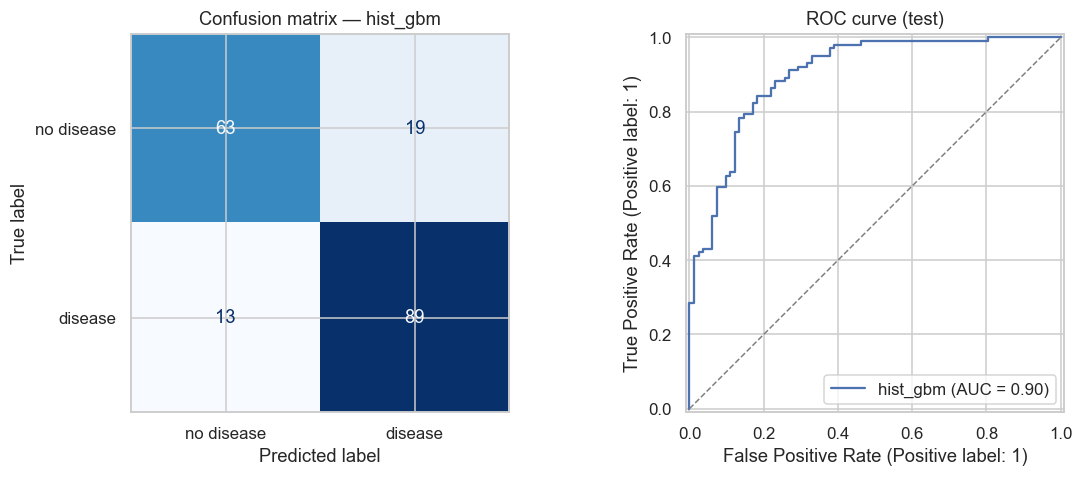

In [26]:
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

test_metrics = {
    "precision": precision_score(y_test, y_pred_test, pos_label=1, zero_division=0),
    "recall":    recall_score(y_test, y_pred_test, pos_label=1, zero_division=0),
    "f1":        f1_score(y_test, y_pred_test, pos_label=1, zero_division=0),
    "roc_auc":   roc_auc_score(y_test, y_proba_test),
}

print(f"Held-out test metrics for '{winner}' (disease class, threshold=0.5):")
for k, v in test_metrics.items():
    print(f"  {k:9s} = {v:.3f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred_test, target_names=["no disease", "disease"], digits=3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=["no disease", "disease"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title(f"Confusion matrix — {winner}")

RocCurveDisplay.from_predictions(y_test, y_proba_test, ax=axes[1], name=winner)
axes[1].plot([0, 1], [0, 1], ls="--", color="gray", lw=1)
axes[1].set_title("ROC curve (test)")

plt.tight_layout()
plt.show()


**Reading these plots.**
- **Confusion matrix (left).** At the default threshold of 0.5, the model catches most diseased patients (recall ≈ 0.87) while flagging a non-trivial minority of healthy patients as disease (specificity ≈ 0.77). The false negatives are exactly the cases the LIME section later dissects — they are informative for threshold tuning.
- **ROC curve (right).** The curve climbs rapidly and plateaus near the top-left corner (AUC ≈ 0.90). The shape tells us the model *ranks* patients by risk reliably, and that there is a broad range of thresholds that trade modest specificity for higher recall — directly relevant given the recall-first selection rule used earlier.
- **Caveat on headline numbers.** These held-out-test numbers are higher than both the tuned cross-validated numbers (AUC ≈ 0.87) and the LOSO-mean (AUC ≈ 0.79 for this run). Part of that gap is a favourable draw of the 184-patient test split. When asking "will this model transport?", judge against **LOSO**, not against a single pooled test partition.

## Interpretation

Three views, each answering a different question:

- **Coefficients / feature importances** — global, structural: *which features does the fitted model lean on on average?*
- **SHAP** — global and local, theoretically grounded attributions that sum (approximately) to the prediction.
- **LIME** — local, surrogate-based explanation of a single prediction, useful for case discussion.

For the pipeline stored in `best_model`, we first pull the fitted preprocessor and classifier so each tool sees the **transformed feature space** (one-hot expanded, scaled).

In [27]:
fitted_prep = best_model.named_steps["prep"]
fitted_clf = best_model.named_steps["clf"]
feature_names_out = fitted_prep.get_feature_names_out()

X_train_t = fitted_prep.transform(X_train)
X_test_t = fitted_prep.transform(X_test)

if hasattr(X_train_t, "toarray"):
    X_train_t = X_train_t.toarray()
    X_test_t = X_test_t.toarray()

print(f"Interpreting: {winner} ({fitted_clf.__class__.__name__})")
print(f"Transformed feature space: {X_train_t.shape[1]} columns")


Interpreting: hist_gbm (HistGradientBoostingClassifier)
Transformed feature space: 25 columns


### Coefficients, feature importances, or permutation importances

Three code paths, selected at runtime:

- **Logistic regression** (`coef_`): coefficients are on the standardized scale, so magnitude is directly comparable across features and sign indicates direction (positive = pushes toward disease).
- **Random forest** (`feature_importances_`): impurity-based importance — how often and how usefully a feature is split on. Scale is relative, not probability or odds-ratio.
- **`HistGradientBoostingClassifier`** (no native importance attribute): fall back to `sklearn.inspection.permutation_importance`, which measures the **drop in ROC-AUC** when each feature is randomly shuffled on held-out data. Model-agnostic, directly interpretable, and computed on the test set here for consistency with the SHAP view below.

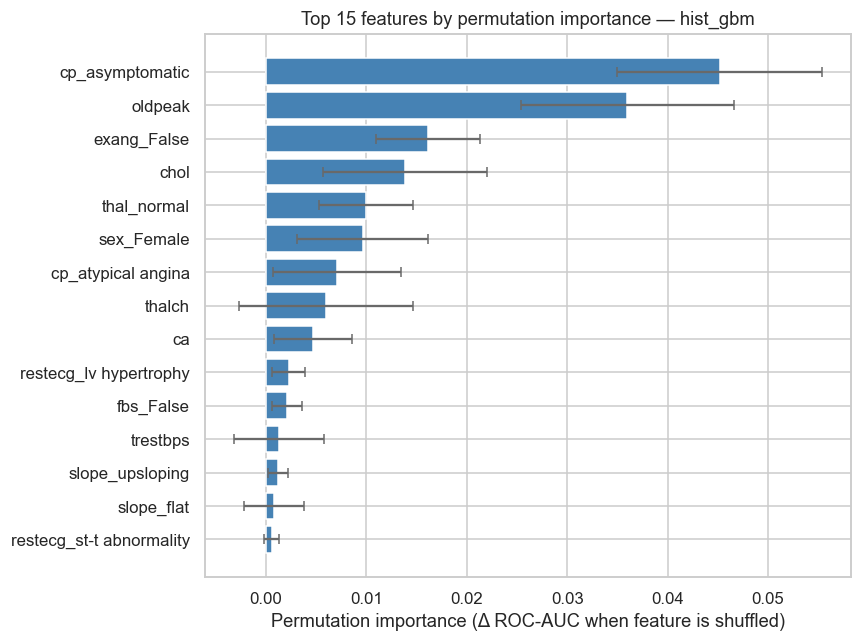

Top 15 features (permutation importance on held-out test, 20 repeats):
                 feature  importance_mean  importance_std
         cp_asymptomatic           0.0452          0.0102
                 oldpeak           0.0360          0.0106
             exang_False           0.0161          0.0052
                    chol           0.0139          0.0082
             thal_normal           0.0100          0.0047
              sex_Female           0.0096          0.0065
      cp_atypical angina           0.0070          0.0064
                  thalch           0.0060          0.0087
                      ca           0.0047          0.0039
  restecg_lv hypertrophy           0.0023          0.0017
               fbs_False           0.0021          0.0015
                trestbps           0.0013          0.0045
         slope_upsloping           0.0012          0.0010
              slope_flat           0.0008          0.0030
restecg_st-t abnormality           0.0006          0.0008


In [28]:
from sklearn.inspection import permutation_importance

if hasattr(fitted_clf, "coef_"):
    coefs = fitted_clf.coef_.ravel()
    imp_df = (pd.DataFrame({"feature": feature_names_out, "coef": coefs})
              .assign(abs_coef=lambda d: d["coef"].abs())
              .sort_values("abs_coef", ascending=False))
    top = imp_df.head(15).iloc[::-1]

    colors = ["steelblue" if c >= 0 else "indianred" for c in top["coef"]]
    plt.figure(figsize=(8, 6))
    plt.barh(top["feature"], top["coef"], color=colors)
    plt.axvline(0, color="black", lw=0.8)
    plt.xlabel("Standardized logistic regression coefficient")
    plt.title("Top 15 features by |coef| (red = lowers disease odds, blue = raises)")
    plt.tight_layout()
    plt.show()

    print("Top 15 features (|coef|):")
    print(imp_df[["feature", "coef"]].head(15).round(3).to_string(index=False))

elif hasattr(fitted_clf, "feature_importances_"):
    imp = fitted_clf.feature_importances_
    imp_df = (pd.DataFrame({"feature": feature_names_out, "importance": imp})
              .sort_values("importance", ascending=False))
    top = imp_df.head(15).iloc[::-1]

    plt.figure(figsize=(8, 6))
    plt.barh(top["feature"], top["importance"], color="steelblue")
    plt.xlabel("Feature importance (impurity-based)")
    plt.title("Top 15 features by importance")
    plt.tight_layout()
    plt.show()

    print("Top 15 features:")
    print(imp_df.head(15).round(4).to_string(index=False))

else:
    perm = permutation_importance(
        fitted_clf, X_test_t, y_test,
        n_repeats=20, scoring="roc_auc",
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    imp_df = (pd.DataFrame({
                  "feature": feature_names_out,
                  "importance_mean": perm.importances_mean,
                  "importance_std":  perm.importances_std,
              })
              .sort_values("importance_mean", ascending=False))
    top = imp_df.head(15).iloc[::-1]

    plt.figure(figsize=(8, 6))
    plt.barh(top["feature"], top["importance_mean"],
             xerr=top["importance_std"], color="steelblue",
             error_kw={"ecolor": "dimgray", "capsize": 3})
    plt.xlabel("Permutation importance (Δ ROC-AUC when feature is shuffled)")
    plt.title(f"Top 15 features by permutation importance — {winner}")
    plt.tight_layout()
    plt.show()

    print("Top 15 features (permutation importance on held-out test, 20 repeats):")
    print(imp_df[["feature", "importance_mean", "importance_std"]]
          .head(15).round(4).to_string(index=False))


### SHAP values

`shap.Explainer` auto-selects a backend (linear for `LogisticRegression`, tree for `RandomForest` / `HistGradientBoosting`). Outputs:

- **Beeswarm** — global feature ranking with per-instance directionality (red = higher feature value, blue = lower).
- **Local bar plot** — attribution breakdown for a single test instance, showing which features pushed the prediction toward or away from disease.

A small random background sample keeps the explainer fast.

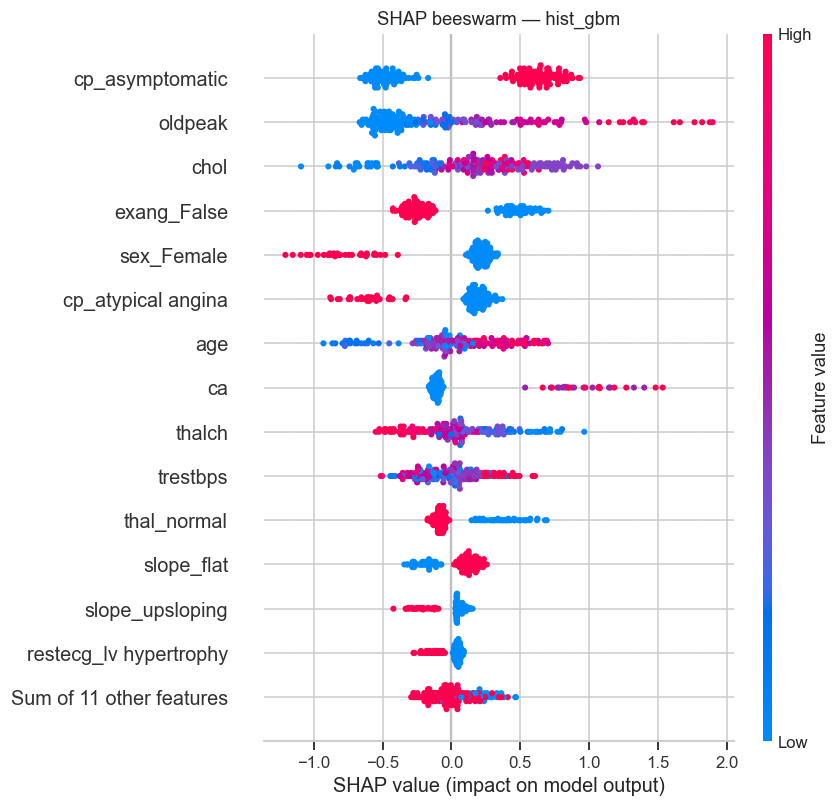

Local explanation for test sample index 112 (true=0, pred_proba(disease)=0.027)


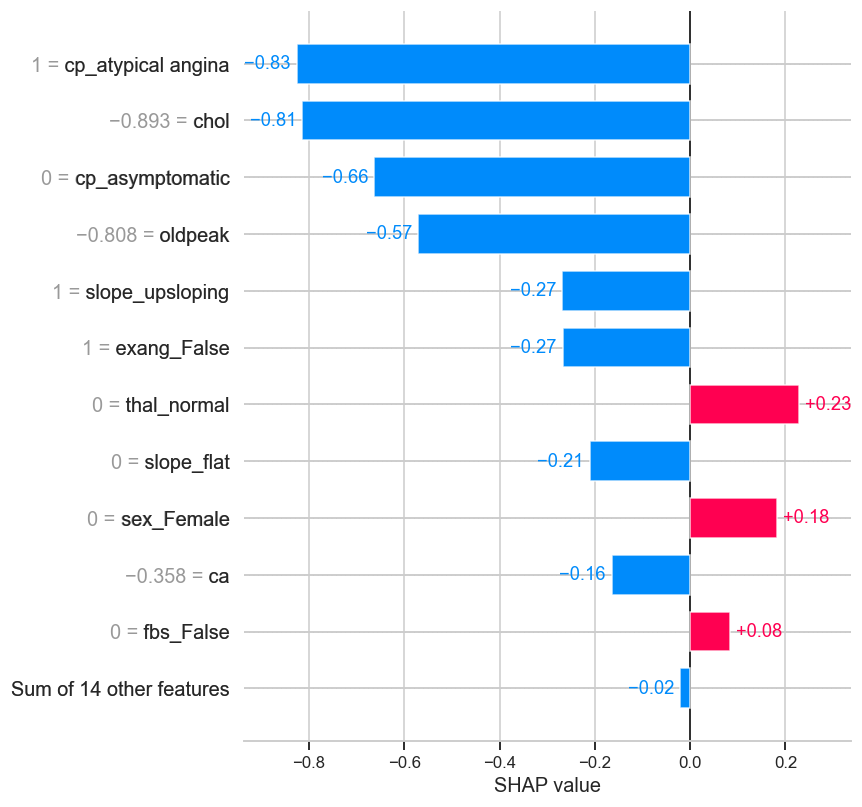

In [29]:
if not _HAS_SHAP:
    print("shap not installed — run `pip install shap` to enable this section.")
else:
    rng = np.random.default_rng(RANDOM_STATE)
    bg_idx = rng.choice(len(X_train_t), size=min(100, len(X_train_t)), replace=False)
    background = X_train_t[bg_idx]

    try:
        explainer = shap.Explainer(fitted_clf, background, feature_names=feature_names_out)
    except Exception:
        explainer = shap.Explainer(
            fitted_clf.predict_proba, background, feature_names=feature_names_out
        )

    sample_size = min(200, len(X_test_t))
    sample_idx = rng.choice(len(X_test_t), size=sample_size, replace=False)
    X_shap = X_test_t[sample_idx]

    shap_values = explainer(X_shap)

    vals = shap_values.values
    if vals.ndim == 3:
        shap_values = shap_values[..., 1]

    plt.figure()
    shap.plots.beeswarm(shap_values, max_display=15, show=False)
    plt.title(f"SHAP beeswarm — {winner}")
    plt.tight_layout()
    plt.show()

    local_i = 0
    print(f"Local explanation for test sample index {sample_idx[local_i]} "
          f"(true={int(y_test.iloc[sample_idx[local_i]])}, "
          f"pred_proba(disease)={y_proba_test[sample_idx[local_i]]:.3f})")
    plt.figure()
    shap.plots.bar(shap_values[local_i], max_display=12, show=False)
    plt.tight_layout()
    plt.show()


**Reading these plots.**
- **Beeswarm (global).** Each dot is one test patient; the x-axis is the contribution to the disease log-odds, and color encodes the feature value (pink = high, blue = low). The top drivers — `cp_asymptomatic`, `oldpeak`, `chol`, `exang_False`, `sex_Female`, `cp_atypical angina`, `age`, `ca`, `thalch`, `thal_normal` — are all directionally sensible clinically (asymptomatic referral, high ST depression, high cholesterol, exercise angina, male, older, lower peak HR, and abnormal thallium all push toward disease).
- **`chol` direction is now clinically sensible.** After the sentinel-zero cleaning step maps `chol = 0` to `NaN` (172 rows in this run), low-cholesterol dots sit on the negative-SHAP side and high-cholesterol dots on the positive side, consistent with hypercholesterolemia as a coronary risk factor. A pre-cleaning run of the same notebook produced a reversed gradient on this row — a good example of how interpretability plots can expose data-quality problems that aggregate metrics hide, and of why the cleaning step belongs *before* the pipeline.
- **Local bar plot.** Attribution breakdown for a single test patient (index printed above). Blue bars = features lowering disease probability for this patient; red bars = raising it. The sum of all contributions plus the baseline gives the predicted log-odds. This is the view to use when discussing a *specific* patient's prediction, as opposed to the global beeswarm which describes the model's behaviour on average.

### LIME — local surrogate explanations

LIME perturbs the inputs around a chosen instance, fits a small interpretable model (sparse linear) on those perturbations, and reports its coefficients as the local explanation. Complementary to SHAP: different assumptions, different failure modes, useful as a cross-check. Two instances are explained — one the model predicts as **disease**, one as **no disease**.


[predicted disease]  test index=1  true=1  p(disease)=0.951
  + disease    w=+0.234   oldpeak > 0.61
  + disease    w=+0.212   0.00 < cp_asymptomatic <= 1.00
  + disease    w=+0.191   sex_Female <= 0.00
  - disease    w=-0.181   ca <= -0.36
  + disease    w=+0.136   exang_False <= 0.00
  + disease    w=+0.106   cp_atypical angina <= 0.00
  + disease    w=+0.083   thal_normal <= 0.00
  + disease    w=+0.074   chol > 0.40
  + disease    w=+0.070   age > 0.68
  - disease    w=-0.064   slope_flat <= 0.00


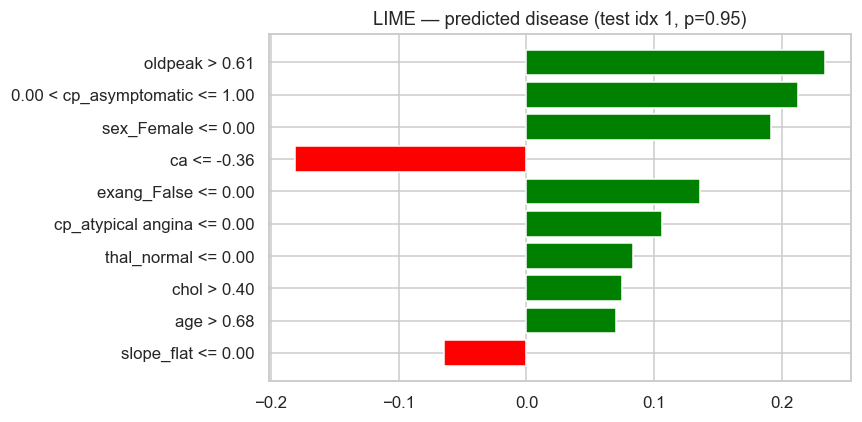


[predicted no disease]  test index=0  true=1  p(disease)=0.473
  + disease    w=+0.194   0.00 < cp_asymptomatic <= 1.00
  - disease    w=-0.194   ca <= -0.36
  + disease    w=+0.177   sex_Female <= 0.00
  - disease    w=-0.152   chol <= -0.54
  - disease    w=-0.141   oldpeak <= -0.81
  - disease    w=-0.138   0.00 < exang_False <= 1.00
  - disease    w=-0.093   thalch > 0.68
  + disease    w=+0.088   cp_atypical angina <= 0.00
  - disease    w=-0.088   0.00 < thal_normal <= 1.00
  + disease    w=+0.067   0.00 < slope_flat <= 1.00


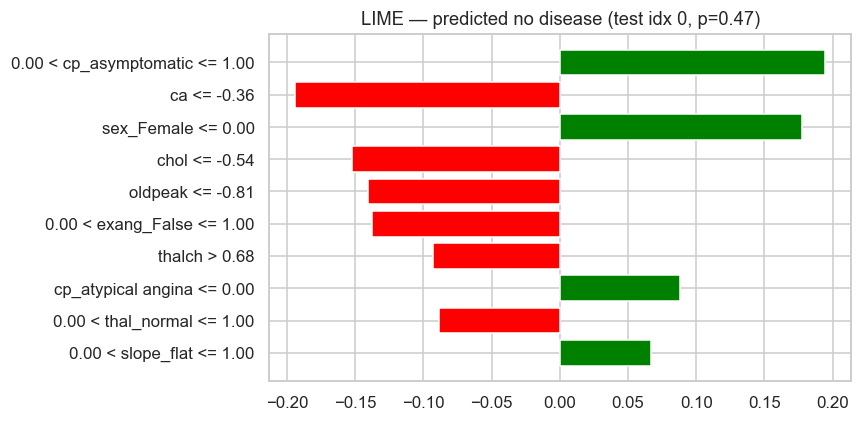

In [30]:
if not _HAS_LIME:
    print("lime not installed — run `pip install lime` to enable this section.")
else:
    lime_explainer = LimeTabularExplainer(
        training_data=X_train_t,
        feature_names=list(feature_names_out),
        class_names=["no disease", "disease"],
        discretize_continuous=True,
        random_state=RANDOM_STATE,
    )

    disease_idx = np.where(y_pred_test == 1)[0]
    healthy_idx = np.where(y_pred_test == 0)[0]
    picks = []
    if len(disease_idx):
        picks.append(("predicted disease", int(disease_idx[0])))
    if len(healthy_idx):
        picks.append(("predicted no disease", int(healthy_idx[0])))

    for label, i in picks:
        exp = lime_explainer.explain_instance(
            data_row=X_test_t[i],
            predict_fn=fitted_clf.predict_proba,
            num_features=10,
        )
        proba = y_proba_test[i]
        true = int(y_test.iloc[i])
        print(f"\n[{label}]  test index={i}  true={true}  p(disease)={proba:.3f}")
        for feat, weight in exp.as_list():
            direction = "+ disease" if weight > 0 else "- disease"
            print(f"  {direction:11s}  w={weight:+.3f}   {feat}")

        fig = exp.as_pyplot_figure()
        fig.set_size_inches(8, 4)
        plt.title(f"LIME — {label} (test idx {i}, p={proba:.2f})")
        plt.tight_layout()
        plt.show()


**Reading these plots.**
- **Correct prediction (top, predicted disease with high probability).** Drivers toward disease line up with the classical ischemic-referral phenotype: asymptomatic chest pain, elevated `oldpeak`, male sex, exercise angina present, abnormal thallium (`thal_normal = 0`), elevated `chol`, and older age. The only substantial pull against disease is low/imputed `ca`. High model confidence on this case is clinically defensible.
- **False negative (bottom, predicted no-disease although truly diseased).** This is exactly the failure mode the recall-first selection rule cares about. Some features point at disease (asymptomatic, male, `slope_flat = 1`) but protective features dominate: very low `oldpeak`, low `chol`, no exercise angina, high `thalch`, normal `thal`, and low/imputed `ca`. The probability lands just below 0.5, not by much — this is a borderline case at the default threshold, not a catastrophic failure. Lowering the decision threshold toward ~0.35–0.40 (tuned on training CV, never on the test set) would recover this patient at modest cost to specificity.
- LIME feature labels are in the **scaled** feature space (post `StandardScaler`), so a threshold like `oldpeak > 0.61` reads as "more than 0.61 training SDs above the training mean", not raw millimetres of ST depression.

## Summary and caveats

- Pipelines were kept strictly leak-free: imputation, scaling, and one-hot encoding were refit inside every CV fold and every randomized-search split.
- Model selection used **ROC-AUC for the inner search** (threshold-free) and **recall → F1 for final choice** (clinical framing: missed disease is costlier than false alarms).
- LOSO variance indicates how much of the performance is site-specific; large spread across sites is a flag that pooled-data estimates may not transport.
- Coefficients, SHAP, and LIME give partly overlapping, partly complementary views. Disagreement between them is information, not a bug — it usually signals non-linear interactions or correlated predictors.
- **This notebook is not a validated clinical tool.** Any downstream use requires prospective validation, governance review, calibration assessment, fairness analysis, and monitoring for drift.

## Key findings

**Model.** A `HistGradientBoostingClassifier` was selected after randomized hyperparameter search (scored on ROC-AUC) with final choice by recall → F1 on the disease class. Tuned 5-fold cross-validated performance on the training partition: **ROC-AUC ≈ 0.87, recall ≈ 0.84, F1 ≈ 0.83**. On the held-out test set: **ROC-AUC = 0.90, recall = 0.87, precision = 0.82, F1 = 0.85**.

**Transportability is limited.** The leave-one-site-out check reveals meaningful site dependence. ROC-AUC drops to ~0.70 when VA Long Beach is held out, versus ~0.84 for Cleveland and ~0.83 for Hungary. LOSO-mean recall (~0.78) stays below pooled cross-validated recall (~0.84), and LOSO-mean ROC-AUC (~0.79) is well below the held-out test (~0.90). **Pooled-data metrics still overstate** how well this model would generalize to a new hospital; site-level calibration and validation would be required before any downstream use. Note: after the sentinel-zero cleaning step was added, LOSO site-to-site variability shrank (std ROC-AUC 0.09 → 0.07), consistent with removing a partially site-correlated data-quality artifact.

**Dominant predictors (SHAP + permutation importance, test set).** `cp_asymptomatic`, `oldpeak`, `exang`, `chol`, `sex`, `thal_normal`, `age`, `ca`, and `thalch` drive most of the signal. Directions are clinically sensible: asymptomatic chest pain at referral, elevated ST depression, exercise-induced angina, elevated cholesterol, male sex, older age, and lower peak heart rate all push toward disease.

**Data-quality caveat surfaced by SHAP (and resolved).** A pre-cleaning run of the notebook showed `chol` ranking near the top of the beeswarm with *low* values pushing toward disease — clinically counter-intuitive and traceable to 172 `chol = 0` sentinel-missing rows that the median imputer could not reach. The **Data cleaning — sentinel zeros** section maps those zeros to `NaN` before the pipeline; in the current run the SHAP colour gradient on the `chol` row is directionally correct (high values → disease). This is a concrete example of how interpretability plots can expose data-quality issues that aggregate metrics hide.

**Operational implications.**
- At threshold 0.5, the model missed 13 of 102 diseased test patients (false-negative rate ≈ 13%). Given the recall-first selection rule, lowering the threshold toward ~0.35–0.40 — tuned on training CV, not on the test set — would recover borderline cases like the LIME-dissected false negative at modest cost to specificity.
- SHAP and LIME agree on the main drivers for correctly-classified and borderline cases. This is a reassuring *internal-consistency* check, not evidence of external validity.

**Caveats and out-of-scope items.** This notebook does not perform calibration assessment, fairness analysis, decision-threshold optimization, prospective validation, or drift monitoring. It is a **methodological template**, not a validated clinical prediction instrument. Any real-world use requires institutional governance review and independent prospective validation on the target population.